In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from aux_functions.ks_data_generator import generate_ks_data, plot_solution, sample_random_u0
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import clear_output
from torchdiffeq import odeint
from tqdm import tqdm


In [3]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


Data shape: (101, 2048)
Test shape: (100, 2048)
Full shape: (201, 2048)


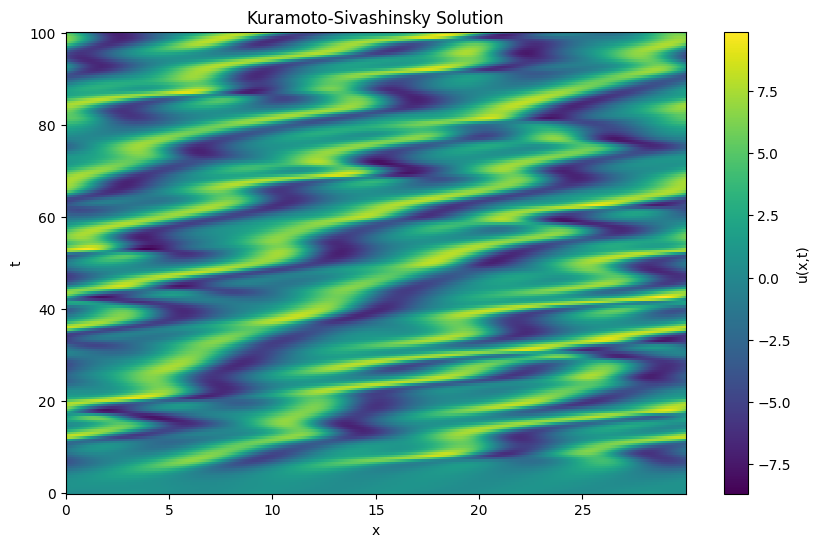

In [6]:
x = np.linspace(0, 30, 2048, endpoint=False)
t = np.linspace(0, 100, 201)
data = np.load('/home/kanbina/code/KS_challenge/data/ks_test_training.npy')
test = np.load('/home/kanbina/code/KS_challenge/data/ks_test_truth.npy')
full = np.concat([data,test])
print("Data shape:", data.shape)
print("Test shape:", test.shape)
print("Full shape:", full.shape)
plot_solution(x, t, full)

# Define Full-Series Windowing for Prediction Horizon
Use prediction-window length $W=\text{len(test)}$, and slide it across the full series from first valid start to last valid start.

In [4]:
U_full = full  # shape: (N, nx)
N_total = U_full.shape[0]
W = test.shape[0]  # prediction-window length

window_start_idx = np.arange(0, N_total - W + 1)
window_end_idx = window_start_idx + W - 1
n_windows = len(window_start_idx)

print(f'N_total={N_total}, W={W}, n_windows={n_windows}')
print(f'Window starts at [{window_start_idx[0]} ... {window_start_idx[-1]}], ends at [{window_end_idx[0]} ... {window_end_idx[-1]}]')

N_total=201, W=100, n_windows=102
Window starts at [0 ... 101], ends at [99 ... 200]


# Compute Time-Averaged Energy in Each Prediction Window
Energy per timestep is $E(t)=\frac{1}{2}\langle u(t,x)^2\rangle_x$. For each window, average $E(t)$ across the window duration.

In [11]:
def compute_instantaneous_energy(u_xt: np.ndarray) -> np.ndarray:
    return 0.5 * np.mean(u_xt**2, axis=1)

instant_energy = compute_instantaneous_energy(U_full)

# Plot Time-Averaged Energy Over Full Data Timeline
The series spans all valid prediction windows from the beginning to the end of the full dataset.

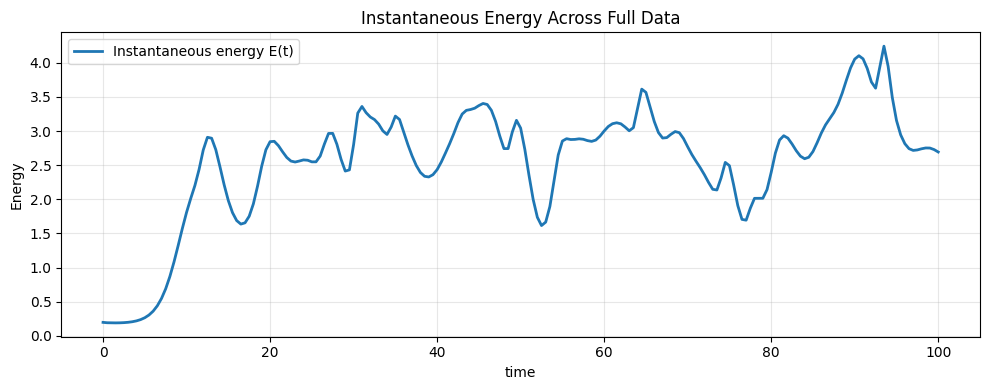

In [12]:
full_time_axis = t if len(t) == N_total else np.arange(N_total)
time_label = 'time'

plt.figure(figsize=(10, 4))
plt.plot(full_time_axis, instant_energy, label='Instantaneous energy E(t)', linewidth=2)
plt.xlabel(time_label)
plt.ylabel('Energy')
plt.title('Instantaneous Energy Across Full Data')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from aux_functions.ks_data_generator import generate_ks_data

def generate_save_plot_data_pair(nu=None, data_dir='data', prefix='ks_data'):
    if nu is None:
        nu = np.random.uniform(2.0, 4.0)

    params = {
        'L': 30,
        'N': 2048,
        'nu': float(nu),
        'dt': 0.5,
        'T': 100.0,
        'num_steps': 201
    }

    x, t, u = generate_ks_data(params)
    split_idx = int((params['num_steps'] - 1) / 2) + 1
    training = u[:split_idx]
    truth = u[split_idx:params['num_steps']]

    os.makedirs(data_dir, exist_ok=True)
    train_path = os.path.join(data_dir, f'{prefix}_training.npy')
    truth_path = os.path.join(data_dir, f'{prefix}_truth.npy')
    np.save(train_path, training)
    np.save(truth_path, truth)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    im0 = axes[0].imshow(training, aspect='auto', origin='lower', cmap='viridis')
    axes[0].set_title(f'{prefix}_training.npy | nu={nu:.4f}')
    axes[0].set_xlabel('Spatial index')
    axes[0].set_ylabel('Time step')
    fig.colorbar(im0, ax=axes[0], shrink=0.85)

    im1 = axes[1].imshow(truth, aspect='auto', origin='lower', cmap='viridis')
    axes[1].set_title(f'{prefix}_truth.npy | nu={nu:.4f}')
    axes[1].set_xlabel('Spatial index')
    axes[1].set_ylabel('Time step')
    fig.colorbar(im1, ax=axes[1], shrink=0.85)

    plt.show()
    print(f'nu used: {nu:.6f}')
    print('Saved:', train_path, training.shape)
    print('Saved:', truth_path, truth.shape)
    return training, truth, params

training, truth, params = generate_save_plot_data_pair()